 # How to Run
1. Begin by setting the granularity to 'q'. (change the accessed element in the list to 0)
2. Set run_every_query to True
3. Update max_quarter and max_month
4. Run All
5. Set the granularity to 'm'. (change the accessed element in the list to 1)
6. Set run_every_query to False and build_ms_df_from_scratch to True
7. Restart Kernel and Run All

In [1]:
import pandas as pd
import numpy as np
import pyodbc
import pickle
import warnings
import time
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
tqdm.pandas()
pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 100)
import openpyxl
import datetime as dt
import re
import os
import copy
#git comment test

In [2]:
granularity = ['q', 'm','w'][1]
run_every_query = True
max_quarter, max_month = 1, 1
max_week = dt.date.today().strftime("%U")
max_week = int(max_week)

In [3]:
def vintage_to_float(vintage):
    """
    Converts a vintage of form 'YYYY QQ' (i.e. '2016 Q2') to a float (i.e. 2016.25)
    The vectorized form of this function for a Series is: pd.to_numeric(df.vintage.str[:4]) + (pd.to_numeric(df.vintage.str[-1]) - 1) / 4
    NOTE: The following formula has been modified to allow for vintages of the form 'YYYY MMM' (i.e. '2016 M06')
    """
    if vintage[5]=='Q':
        return int(vintage[:4]) + (int(vintage[-1]) - 1) / 4
    elif vintage[5]=='M':
        return int(vintage[:4]) + (int(vintage[-2:]) - 1) / 12
    

def float_to_vintage(vintage_float):
    """
    Converts a vintage as a float (i.e. 2016.25) to a str of form 'YYYY QQ' (i.e. '2016 Q2')
    The vectorized form of this function for a Series is: 
        df.vintage_float.astype(int).astype(str) + ' Q' + ((df.vintage_float % 1) * 4 + 1).astype(int).astype(str)
    """
    return str(int(vintage_float)) + ' Q' + str(int((vintage_float % 1) * 4 + 1))
    
"""
SQL and Files
"""
def run_sql(filename, sub_list=[], connection=None, filename_is_query=False):
    """
    Run a SQL Query by reading from a .txt file, substituting values when required.
    Input:
    filename (str): File that we want to read. Usually a .txt file.
    sub_list (list of (str,str) tuples): Substitute each instance of the first element of the tuple for the second.
                                         Example: [('{max_mob}', '6')]
    """
    if filename_is_query:
        query = filename
    else:
        with open(filename, 'r') as file:
            query = file.read()
    for sub in sub_list:
        text, var = sub
        query = query.replace(text, var)
#     print(query)
    if connection is None:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            warnings.filterwarnings("ignore", category=UserWarning)
            df = pd.read_sql_query(sql=query, con=conn)
            warnings.filterwarnings("default", category=UserWarning)
            return df
    else:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=connection)
        warnings.filterwarnings("default", category=UserWarning)
        return df

def store_pickle(data, filename):
    """
    Stores a pickle of the given data at the given filename, in a simplified function call
    """
    # Perform a swap if I got the order of data and filename backwards
    if type(data)==str:
        temp = filename
        filename = data
        data = temp
    with open(filename, 'wb') as file:
        pickle.dump(data, file)

def get_pickle(filename):
    """
    Loads a pickle in a simplified function call
    """
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    return data

def smooth(series):
    """
    Calculates a centered average by averaging the previous two values and following two values, as well as the current value.
    Handles the first and last two values separately.
    """
    averaged_series = pd.Series(index=series.index, dtype=float)  # Create an empty Series to store the averaged values
    
    # Handle the first value separately
    averaged_series.iloc[0] = series.iloc[0]
    averaged_series.iloc[1] = (series.iloc[0] + series.iloc[1] + series.iloc[2]) / 3
    
    # Calculate the running average for the middle values
    for i in range(2, len(series) - 2):
        averaged_series.iloc[i] = (series.iloc[i-2] + series.iloc[i-1] + series.iloc[i] + series.iloc[i+1] + series.iloc[i+2]) / 5
    
    # Handle the last value separately
    averaged_series.iloc[-1] = series.iloc[-1]
    averaged_series.iloc[-2] = (series.iloc[-1] + series.iloc[-2] + series.iloc[-3]) / 3
    
    return averaged_series
def weight_by_proceeds(metric, proceeds):
    """
    Function to get the average of a given Series, weighted by Amount Financed.
    """
    return (metric * proceeds).sum() / proceeds.sum()
def weighted_average_and_sum(group, metrics):
    """
    Function that gets the weighted average of a Series (or several series), 
        returning the averages and the sum of Amount Financed.
    """
    if type(metrics)==str:
        weighted_avg = (group[metrics] * group.amt_financed).sum() / group.amt_financed.sum()
        return pd.Series({metrics: weighted_avg, 'amt_financed': group.amt_financed.sum()})
    result_dict = {'amt_financed': group.amt_financed.sum()}
    for metric in metrics:
        weighted_avg = (group[metric] * group.amt_financed).sum() / group.amt_financed.sum()
        result_dict[metric] = weighted_avg.sum()
    return pd.Series(result_dict)

# Old Recovery Model

In [4]:
def auc_pred(rra_df, leave_out, rra_lob_df=None):
    """
    Recovery model used by the pricing team to determine the expected recovery of a vehicle when it is sold.
    KMX uses a different recovery model, so it's handled separately.
    This function was made to support "Leave Out" analysis, which isn't included in the Ragu jar. 
        That's what all the if/else statements are for.
    This function has been vectorized as much as possible, but it's possibly not totally optimized.
    Inputs:
        rra_df (pd.DataFrame object): Data containing vehicle info. Each row is a vehicle, and each row is analyzed separately.
        leave_out (str): Factor to not consider in this runthrough. Helps us understand how much of a role each factor plays.
        rra_lob_df (pd.DataFrame): Only used in Leave Out analysis. Contains every vehicle for every vintage for this LOB.
    Outputs:
        recovery_multiplier (pd.Series): Column to add to rra_df containing the % of original vehicle value we expect to recover.
    """
    if len(rra_df[rra_df.lob=='KMX']) > 0:
        conditions = [
            (rra_df.car_age_orig < 3),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig == 3) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price >= 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price < 30000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price >= 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig >= 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price >= 40000)
        ]

        values = [3300, 3700, 5400, 7200, 4700, 6400, 8200, 5700, 7400, 9200]

        recovery_amount = np.maximum(0, rra_df.sale_price - np.select(conditions, values, default=0))

        return recovery_amount * (1 - 0.206) ** rra_df.yob / rra_df.sale_price


    rra_df['coef_intercept'] = 0.0891185245
    rra_df['coef_yob'] = -0.2668087106 * rra_df.yob


    if leave_out != 'Mileage/age':
        rra_df['coef_mlg_x_age'] = 0.0001463508 * rra_df.car_age_orig * rra_df.mileage - 0.0004310013 * rra_df.car_age_orig - 0.0033127224 * rra_df.mileage
    else: 
        rra_df['coef_mlg_x_age'] = np.log((np.exp(0.0001463508 * rra_lob_df.car_age_orig * rra_lob_df.mileage) * np.exp(-0.0004310013 * rra_lob_df.car_age_orig) * np.exp(-0.0033127224 * rra_lob_df.mileage)).mean())
    if leave_out != 'Japanese':
        rra_df['coef_japanese'] = rra_df.car_japanese.map({'Japanese': 0.1004702010, 'Other': 0})
    else:
        rra_df['coef_japanese'] = np.log(rra_lob_df.car_japanese.map({'Japanese': np.exp(0.1004702010), 'Other': np.exp(0)}).mean())
    if leave_out != 'Vehicle class':
        rra_df['coef_class'] = rra_df.car_class_only.map({'Compact': 0.0303893787,
                                        'Minivan': np.log(0.975),
                                        'Sporty': 0.0758593720,
                                        'SUV Large': -0.0237364286,
                                        'SUV Small': 0.0190370746,
                                        'Work Van': 0,
                                        'Truck': 0.1436074633,
                                        'Car': 0, 'Other':0})
    else:
        rra_df['coef_class'] = np.log(rra_lob_df.car_class_only.map({'Compact': np.exp(0.0303893787),
                                                             'Minivan': np.exp(np.log(0.975)),
                                                             'Sporty': np.exp(0.0758593720),
                                                             'SUV Large': np.exp(-0.0237364286),
                                                             'SUV Small': np.exp(0.0190370746),
                                                             'Work Van': np.exp(0),
                                                             'Truck': np.exp(0.1436074633),
                                                             'Car': np.exp(0), 'Other':np.exp(0)}).mean())
    if leave_out != 'Fuel type':
        rra_df['coef_fuel'] = rra_df.fuel_type.map({'Hybrid': -0.0315481529,
                                       'Flex': 0.0255682747,
                                       'Diesel': -0.1284314925,
                                       'EV': np.log(0.9),
                                       'Gas': 0})
    else:
        rra_df['coef_fuel'] = np.log(rra_lob_df.fuel_type.map({'Hybrid': np.exp(-0.0315481529),
                                                    'Flex': np.exp(0.0255682747),
                                                    'Diesel': np.exp(-0.1284314925),
                                                    'EV': np.exp(np.log(0.9)),
                                                    'Gas': np.exp(0)}).mean())
    if leave_out != 'Luxury classification':
        rra_df['coef_lux'] = rra_df.car_lux.map({'Luxury': -0.1108317813, 'Standard': 0})
    else:
        rra_df['coef_lux'] = np.log(rra_lob_df.car_lux.map({'Luxury': np.exp(-0.1108317813), 'Standard': np.exp(0)}).mean())
    if leave_out != 'LOB':
        rra_df['coef_lob'] = rra_df.lob.map({'ENT': 0.0405731662,
                                      'FLD': 0.0405731662,
                                      'FRN': -0.0277901296,
                                      'STG': 0.0263749504,
                                      'AN': 0})
    else:
        rra_df['coef_lob'] = np.log(rra_lob_df.lob.map({'ENT': np.exp(0.0405731662),
                                              'FLD': np.exp(0.0405731662),
                                              'FRN': np.exp(-0.0277901296),
                                              'STG': np.exp(0.0263749504),
                                              'AN': np.exp(0)}).mean())
    if leave_out != 'Driver flag':
        rra_df['coef_driver'] = (-0.0918049638) * rra_df.driver_flag
    else:
        rra_df['coef_driver'] = np.log(rra_lob_df.driver_flag.map({1:np.exp(-0.0918049638), 0: np.exp(0)}).mean())
    if leave_out != 'Impound probability':
        rra_df['coef_impound'] = (-0.2803330880) * rra_df.impound_prob
    else:
        rra_df['coef_impound'] = np.log(np.mean(np.exp((-0.2803330880) * rra_lob_df.impound_prob)))
    
    try:
        # code that may raise an exception

        rra_df=rra_df.dropna()
        for col in ['coef_intercept', 'coef_yob', 'coef_mlg_x_age', 'coef_japanese', 'coef_class', 'coef_fuel', 'coef_lux', 
                    'coef_lux', 'coef_lob', 'coef_driver', 'coef_impound']:
            print(col)
            assert len(rra_df)==len(rra_df.dropna(subset=col))
    except Exception as e:
        # code to handle the exception
        print(col, ';', rra_df.fuel_type.unique())
        print(len(rra_df) - len(rra_df.fuel_type.dropna()))
        print(rra_df)
        store_pickle('rra_df_pickle_exception',rra_df)
        raise Exception()

    return rra_df.r_mmi * np.exp(rra_df.coef_intercept + rra_df.coef_yob + rra_df.coef_mlg_x_age + rra_df.coef_japanese\
                                 + rra_df.coef_class + rra_df.coef_fuel + rra_df.coef_lux + rra_df.coef_lob\
                                 + rra_df.coef_impound + rra_df.coef_driver)

In [5]:
def get_ula_multiplier_nonkmx(ula_df, leave_out):

    ula_df['loss_multiplier'] = 1


    print(ula_df.loss_multiplier.mean())


    if leave_out !='Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag # loss_adj_01_acaco: 1 or 1.1

    print("Previous ACA chargeoff: " + str(ula_df.prev_co_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag *(1- ula_df.pricing_change_flag) # loss_adj_02_small_amtfin: 1 or 1.1

    print("small atf: " + str(ula_df.small_amt_financed_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag) # loss_adj_03_zero_down: 1 or 1.1

    print("zero cd: " + str(ula_df.zero_cash_down_flag.mean()))
    print(ula_df.loss_multiplier.mean())



    if leave_out!='High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag # loss_adj_04_high_mileage: 1 or 1.1


    print("high miles: " + str(ula_df.high_mileage_vehicle_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag) # loss_adj_05_high_PTI: 1 or 1.1


    print("high pti: " + str(ula_df.high_mileage_vehicle_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Car make':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.car_make_penalty_flag\
                                    - 0.1 * ula_df.car_make_benefit_flag - 0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag
                                    #+  0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag*ula_df.ent_fld_flag # loss_adj_06_vehicle_make: 1 or 0.9 or 1.1

    print("toyho: " + str(ula_df.car_make_benefit_flag.mean()))
    print(ula_df.loss_multiplier.mean())

    if leave_out!='Theft risk':
        ula_df.loss_multiplier *= 0.987 + 0.099 * ula_df.theft_risk_flag * (1-ula_df.pricing_change_flag) + 0.013*ula_df.pricing_change_flag  # loss_adj_09_theft_risk: 0.987 or 1.086

    print("theft risk: " + str(ula_df.theft_risk_flag.mean()))
    print(ula_df.loss_multiplier.mean())

    if leave_out!='MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag # loss_adj_07_new_MCY: 1 or 0.8
    if leave_out!='Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag\
                                    + 0.02 * ula_df.weekday_flag # loss_adj_08_day_of_week: 1 or 0.95 or 1.02

    #
    #
    # print(ula_df.loss_multiplier)
    # print("pre everything")


         # MS - 130 for all LOB's except ENT where it's MS - 128
    if leave_out !='Student Loans':
        ula_df.loss_multiplier *= 1 + (0.1 * ula_df.student_loan_flag \
                                            - np.minimum( np.maximum( (ula_df.cd_model_score - (130 - 2 * ula_df.ent_flag)) * 0.006, 0 ), 0.03) * (1 - ula_df.student_loan_flag))*(ula_df.student_loans_cutoff_date)




    #
    # print(ula_df.loss_multiplier)
    # print("student loans")

    if leave_out != 'Low PTI':
        # print(ula_df.loss_multiplier)
        ula_df.loss_multiplier *= 1 + (-0.03 * np.minimum(ula_df.cd_model_score, 135) + 3.9) * ula_df.low_pti_flag



    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.966 + 0.273 * ula_df.nonkmx_chime_flag 
        #ula_df.loss_multiplier *= 0.989 + 0.111 * ula_df.secured_credit_flag # loss_adj_10_secured_card: 0.989 or 1.1

    print("chime")
    print(ula_df.loss_multiplier.mean())

    print("chime counts" + str(ula_df.nonkmx_chime_flag.count()))
    print("chime avg: " + str(ula_df.nonkmx_chime_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag\
                                    - 0.1 * ula_df.waiter_employment_flag # loss_adj_11_employment: 1 + 0.1 * cust_attr$employment_flag
    if leave_out!='Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag # loss_adj_13_authorized_tradeline: 1 or 1.1


    if leave_out != 'Fraud':
        ula_df.loss_multiplier *= 1  + (ula_df.fraud_adjustment -1)



    if leave_out != 'Driver flag':
        ula_df.loss_multiplier *= 1 + 0.15 * ula_df.driver_flag



    if leave_out!='Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.8, 2) #previously (0.8,1.2)
    #if leave_out!='Null FICO with Vantage':
        #ula_df.loc[ula_df['fico_adjustment_flag'] == 1, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag # loss_adj_14_non_fico: 0.99 or 1.1
    if leave_out!='Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4) #previously (0.8,1.2)
    # if leave_out!='Dealer Level (Non-KMX)':
    #     ula_df.loss_multiplier *= 1 - 0.2 * (ula_df.lob_or_bucket == 'A').astype(int) \
    #                                 - 0.1 * (ula_df.lob_or_bucket == 'B').astype(int) \
    #                                 + 0.09 * (ula_df.lob_or_bucket == 'D').astype(int) \
    #                                 + 0.2 * (ula_df.lob_or_bucket == 'E').astype(int)
        #change for lob dll ragu
    # The following is a pricing adjustment, but we don't include it, since it's macroeconimic (that's what the loss committee predicts)
#       #Additional loss adjustment to ensure losses match loss committe predictions
#   lob_scalar <- ifelse(app_attr$lob == "AN", 1.045,
#                        ifelse(app_attr$lob == "FLD", 1.09,
#                               ifelse(app_attr$lob == "FRN", 0.925,
#                                      ifelse(app_attr$lob == "STG", 0.996, 1))))
    return ula_df

In [6]:
def get_ula_multiplier_kmx(ula_df, loss_scale=0.067, leave_out='None'):
    ula_df['loss_multiplier'] = 1




    if leave_out!='Job time':
        # 0.99 counter
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag

    if leave_out!='Low FICO':
        # remove
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag)


    if leave_out!='Low Vantage':

        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag)

    # if leave_out!='Louisiana':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag

    if leave_out!='High PTI':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0 * ula_df.normal_pti_flag \
                                    + 0.05 * ula_df.high_pti_tier_1_flag \
                                    + 0.1 * ula_df.high_pti_tier_2_flag \
                                    + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag
    if leave_out!='Existing DQ':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.1 * ula_df.existing_dq_flag
    if leave_out!='Employment type':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] /= (1 + loss_scale)

    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured_credit_flag)\
                                        * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag)

    if leave_out!='Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
    if leave_out!='Null FICO with Vantage':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag + 0.01 * ula_df.null_fico_null_vantage_flag
    if leave_out!='Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025
                                                               + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108
                                                                                                   + ula_df.secured_credit_flag * 0.295))

    if leave_out != 'Fraud':
        # print("bef", ula_df.loss_multiplier)
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + (ula_df.fraud_adjustment - 1)
        # print("aft", ula_df.loss_multiplier)
        # print("fraud", ula_df.fraud_adjustment)






    if leave_out!='Clip': #verified
        clipped_multiplier = np.clip(ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'], 0.8, 1.35 / (1 + loss_scale))

        ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'] = clipped_multiplier


        # clipped_multiplier = np.clip(ula_df[~ula_df.high_pti_tier_3_flag].loss_multiplier, 0.8, 1.35 / (1 + loss_scale))
        #
        # ula_df.loc[~ula_df.high_pti_tier_3_flag & ~ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier






    if leave_out!='Vehicle Age':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier']  *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age


    #Mountain 3.1 Gross Loss Adjustments
    # MTN 3.2 is exactly the same as 3.1


    # add low vantage to 3.1: vantage 5-475, if soft pull then 1.1x counter 0.99, no soft pull 1.2x v 0.98, NA no adjustment

    # 3.1: cash down % penalty:
    # add npc flag, every loan using npc, if pti > 0.2 then penalty is 1.1x and 0.99
    # student loans: if pb or cb has student stu loans, 1.1x and 0.96 counter
    #driver flag, 1.15x no counter, use same determination as nonkmx





    #4.1 has adjustment for >30k sales price. 1.15,  counter is 0.97
    #everything in 3.1 is also in 4.1 + the sales price


    if leave_out !='npc':
        ula_df.loc[ula_df.kmx_npc_flag, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.high_pti_npc




    if leave_out != 'Student Loans':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.96 +  0.14 * ula_df.student_loan_flag




    if leave_out != 'high sales price':
        ula_df.loc[ula_df.mtn_model.isin([4.1]),'loss_multiplier'] *= 0.98 + 0.22 * ula_df.high_sales_price_flag


    if leave_out != 'Driver flag':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.15 * ula_df.driver_flag






    if leave_out!='Louisiana':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier']  *= 1 + 0.35 * ula_df.louisiana_flag
        # print(in )

    if leave_out!='georgia':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier']  *= 1 + 0.1 * ula_df.georgia_flag

    if leave_out!='txca':
        # MS > 140 get 0.9 benefit, 135-140 get 0.95 benefit
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score > 140) ,'loss_multiplier']  *= 1 - 0.1 * ula_df.txca_flag
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score <= 140) &  (ula_df.cd_model_score >= 135)   ,'loss_multiplier']  *= 1 - 0.05 * ula_df.txca_flag


    if leave_out!='state_counter_adj':
        ula_df.loc[ ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1])  & (ula_df.cd_model_score < 150) & ~(ula_df.louisiana_flag | ula_df.georgia_flag | ula_df.txca_flag) ,'loss_multiplier'] *= 1.012





    if leave_out!='Secured credit (Chime, etc.)': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.96 + (0.01 * ula_df.soft_pull_flag  - 0.18*ula_df.chime_flag* ula_df.soft_pull_flag) + 0.46*ula_df.chime_flag

    if leave_out!='Job time': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag

    if leave_out!='Existing DQ': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.11 * ula_df.existing_dq_flag

    if leave_out!='Employment type': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag





    if leave_out!='Authorized tradelines': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag




    if leave_out!='Soft pull': #verified

        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1  * (0.99 + 0.11*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)



        # verified
          #verified

        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ~ula_df.soft_pull_flag,'loss_multiplier'] *= (1 * (0.98 + 0.22*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag)  * (0.945 + 0.405*ula_df.open_tl_flag ) /np.maximum(ula_df.cd_perc_flag*ula_df.open_tl_flag*1.2,1)) #verified


                                                                                                          # verified
 #verified




    # if leave_out!='Soft pull':
    #     ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1 * (0.97 + 0.23*ula_df.secured_credit_flag) * (0.995 + 0.03*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)
    #     ula_df.loc[ula_df.mtn_3_1_flag & ~ula_df.soft_pull_flag,'loss_multiplier'] *= 1 * (0.98 + 0.32*ula_df.secured_credit_flag) * (0.9767 + 0.2233*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag) * (0.945 + 0.405*ula_df.open_tl_flag )/np.maximum(ula_df.cd_perc_flag*ula_df.open_tl_flag*1.2,1)

    ula_df.loc[ula_df.mtn_3_1_flag,'loss_multiplier']/=1.1


    if leave_out!='Clip':

        # verified, use the same clip for 4.1
        # clipped_multiplier = np.clip(ula_df[ula_df.mtn_3_1_flag].loss_multiplier, 0.75, 1.4)
        # ula_df.loc[ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier



        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] = np.clip(ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'], 0.75, 1.4)


    for model in [3.0, 3.1, 3.2, 4.1]:
        mean_val = ula_df.loc[ula_df.mtn_model == model, 'loss_multiplier'].mean()
        print(f"mtn_model {model}: mean loss_multiplier = {mean_val}")






    # if leave_out!='Car make':
    #     ula_df.loss_multiplier *= 1 - 0.08*ula_df.kmx_toyho_flag
    #
    return ula_df

## Fetch MS

In [7]:
"""
Refetch the original model scores, untainted by any modification by analysis.
"""
run_query = False
if run_query or run_every_query:
    all_original_model_scores = run_sql('postmodern_ms_query.txt', sub_list=[('{min_book_date}', "'2016-01-01'")])
    store_pickle(all_original_model_scores, 'all_original_model_scores_pickle')
else:
    all_original_model_scores = get_pickle('all_original_model_scores_pickle')
all_original_model_scores.book_date = all_original_model_scores.book_date.astype(str)
all_original_model_scores.book_week = all_original_model_scores.book_week.astype(str)
#print(all_original_model_scores.book_date)
if granularity == 'q':
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + ' Q' + ((all_original_model_scores.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
elif granularity == 'm':
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + ' M' + all_original_model_scores.book_date.str[5:7]
else:
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + '-'+ all_original_model_scores.book_week.str.zfill(2)
    
original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
original_model_scores = pd.concat([original_model_scores, all_original_model_scores.groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('POS')
original_model_scores = pd.concat([original_model_scores, all_original_model_scores[all_original_model_scores.lob.isin(['AN', 'STG', 'FRN', 'FLD'])].groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('non_kmxent')
ms_df = original_model_scores.copy()

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\2930573717.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\2930573717.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_model_scores = pd.concat([original_m

In [8]:
ms_df.head()

,vintage,lob,model_score,amt_financed
0,2016 M01,AN,129.760371,7781530.53
1,2016 M01,FLD,136.535021,76648.00
2,2016 M01,FRN,128.589400,3254221.42
3,2016 M01,KMX,133.360584,918367.86
4,2016 M01,STG,129.003442,8187381.84


In [9]:
def get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, new_recovery, leave_out='None'):
    """
    This function provides the core of RAGU Score analysis.
    There are three parts to this code:
        1. Get Unit Loss Adjustments: Modify the probability of chargeoff based on factors not included in Model Score.
        2. Get Recovery Rate Adjustments: Use auc_pred() to calculate how much we'll recover if the vehicle sells.
        3. Group it all together: Group based on granularity, applying the RAGU Score calculation formulas (see PowerPoint).
            This section rolls up by LOB, but if there are multiple LOBs (for non_kmxent), group by that in addition.
    Inputs:
        vintage (str): Monthly or quarterly vintage (for example, "2022 M03" or "2022 Q1") we want results for
        lob (str or tuple of str): LOB we want results for.
            If multiple are provided, they are assessed in the context of each other, but still separate.
        lob_type (str): Higher-order group. For KMX and ENT, this is the same as LOB, but for other LOBs, this is 'non_kmxent'
        ula_df_total (pd.DataFrame object): DataFrame containing every vehicle's ULA-related info throughout ACA history.
        rra_df_total (pd.DataFrame object): DataFrame containing every vehicle's RRA-related info throughout ACA history.
        leave_out (str): For Leave Out analysis, what factor to leave out. This helps us assess how much impact each factor has.
    Outputs:
        full_df (pd.DataFrame): DataFrame containing the results of RAGU Score analysis for the given vintage and LOB(s).
            All columns are weighted averages unless otherwise noted.
            Columns: 'amt_financed_x': Sum of amount financed for this grouping
                     'loss_multiplier': Result of ULA.  What % more or less the unit loss rate should be.
                     'recovery_unadjusted_multiplier': % of original vehicle value we expect to recover, not adjusted for LTV or baseline.
                     'ltv': LTV of grouping
                     'bbvalue': BlackBook value of grouping. For KMX, this is sale price instead.
                     'ltv_realization_factor': Unused. Factor to determine how much benefit from LTV we're seeing.
                     'recovery_100_ltv_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, assuming 100% impact.
                     'recovery_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, after ltv_realization_factor.
                     'vintage': Vintage for this grouping.
                     'model_score': Model score for this grouping. Same as ms_original.
                     'amt_financed_y': Unused. Sum of amount financed for this grouping, using different parts of ms_df. Nearly the same as amt_financed_x.
                     'est_unit_loss': Probability of chargeoff. Currently set to mean_unit_loss. We may eventually modify this to convert the Unit Loss Score to a Unit Loss %.
                     'unit_loss_score': Model Score adjusted for ULA.
                     'ms_original': Model score for this grouping. Same as model_score (for the moment, this may change when we get better historical values for the current model).
                     'baselined_recovery': recovery_multiplier / baseline_recovery_pct. How much better/worse we're doing for this grouping compared to the grouping's baseline.
                     'baselined_unadjusted_recovery': recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct
                     'baselined_100_ltv_recovery': recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct
                     'ms_gla': Renamed Unit Loss Score
                     'ms_exclude_ltv': RAGU Score without any LTV impacts. Because we have some issues with LTV, this is the score we use, taking LTV adjustments in the Excel.
                     'ms_100_ltv': RAGU Score assuming 100% LTV impacts.
                     'ragu_score': RAGU Score using baselined_recovery. Uses the RAGU formulas.
    """
    # Get the Unit Loss Adjustment Multiplier
    if type(lob)==str:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob==lob)].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob==lob)].copy()
    else:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob.isin(lob))].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob.isin(lob))].copy()


    if lob == 'KMX':
        loss_scale = 0.067
        ula_df = get_ula_multiplier_kmx(ula_df, loss_scale, leave_out)
    else:
        ula_df = get_ula_multiplier_nonkmx(ula_df, leave_out)
    ula_df = ula_df[['account_number', 'book_date', 'bbvalue', 'sale_price', 'amt_financed', 'lob_or_bucket', 'lob', 'loss_multiplier']]



    # Get the Recovery Rate Adjustment Multiplier
    if leave_out == 'None':
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob==lob)].copy()
            new_rec = new_recovery[(new_recovery.vintage==vintage)&(new_recovery.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob.isin(lob))].copy()
            new_rec = new_recovery[(new_recovery.vintage==vintage)&(new_recovery.lob.isin(lob))].copy()
    else:
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.lob==lob)].copy()
            new_rec = new_recovery[(new_recovery.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.lob.isin(lob))].copy()
            new_rec = new_recovery[(new_recovery.lob.isin(lob))].copy()

    try:
        rra_df.car_year = rra_df.car_year.fillna(round(rra_df.car_year.mean()))
    except:
        store_pickle('rra_df_pickle_exception',rra_df)
    # Note: ceil(car_age_orig) = ula_df's vehicle_age column
    rra_df['car_age_orig'] = np.maximum((pd.to_datetime(rra_df.book_date) - pd.to_datetime(rra_df.car_year.astype(int).astype(str) + '-09-01')).dt.days / 365, 1 / 365)



    rra_df = rra_df.merge(new_recovery[['account_number', 'new_recovery_multiplier']],
                      on='account_number',
                      how='left')


    if leave_out == 'None':
        # rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out)
        rra_df['recovery_multiplier'] = rra_df['new_recovery_multiplier']
    else:
        rra_lob_df = rra_df.copy()
        rra_df = rra_df[rra_df.vintage==vintage]
        rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out, rra_lob_df)


    rra_df = rra_df[['account_number', 'recovery_multiplier']]
    mix_df = ula_df.merge(rra_df, on='account_number', how='inner').drop_duplicates(subset='account_number', keep='first')
    bb_populated_df = mix_df.dropna(subset='bbvalue')
    bb_populated_df['ltv'] = bb_populated_df.amt_financed / bb_populated_df.bbvalue
    bb_populated_df['recovery_unadjusted_multiplier'] = rra_df['recovery_multiplier']   #skip_rate * bb_populated_df.recovery_multiplier.copy()




    # Group by LOB
    # bb_populated_df.reset_index()

    grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])

    #wtd mult

    # bb_populated_df.reset_index()

    # Calculate these values after rollup to match the LTV graph better.
    grouped_mix_df['ltv_realization_factor'] = 0 # 1 - ltv_realization_dollar / (grouped_mix_df.recovery_unadjusted_multiplier * grouped_mix_df.bbvalue)
    grouped_mix_df['recovery_100_ltv_multiplier'] = 0 # (grouped_mix_df.recovery_unadjusted_multiplier * baseline_ltv / grouped_mix_df.ltv).copy()
    grouped_mix_df['recovery_multiplier'] = 0 # grouped_mix_df.recovery_unadjusted_multiplier * (1 + (baseline_ltv / grouped_mix_df.ltv - 1) * grouped_mix_df.ltv_realization_factor)
    vintage_ms_df = ms_df[ms_df.vintage==vintage].copy()
    #store_pickle('vintage_ms_df_keyerror', vintage_ms_df)
    #store_pickle('grouped_mix_df_keyerror', grouped_mix_df)

    #wrapp

    # vintage_ms_df = vintage_ms_df.reset_index(drop = True) #revert to original, remove line

    # grouped_mix_df = grouped_mix_df.reset_index(drop = False) #revert to original, remove line



    index_name = grouped_mix_df.index.name
    if type(index_name) == str and index_name in grouped_mix_df.columns:
    # 'lob' already exists as a column; don't re-insert it
        grouped_mix_df = grouped_mix_df.reset_index(drop=True)
    else:
        grouped_mix_df = grouped_mix_df.reset_index()




    full_df = grouped_mix_df.merge(vintage_ms_df, on='lob')



    full_df['est_unit_loss'] = mean_unit_loss
    full_df['unit_loss_score'] = full_df.model_score + (1 - full_df.loss_multiplier) * full_df.est_unit_loss / unit_loss_to_model_score
    full_df = full_df.set_index('lob')
    # Step 1: Get Model Score
    full_df['ms_original'] = full_df.model_score.copy()
    # Step 2: Adjust Model Score by Pricing Adjustments (This includes Unit Loss and pre-LTV Recovery adjustments)
    full_df['baselined_recovery'] = 0 # (full_df.recovery_multiplier / baseline_recovery_pct).copy()
    # full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct).copy()

    full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / new_baseline_recovery_unadjusted_pct).copy()


    full_df['baselined_100_ltv_recovery'] = 0 # (full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct).copy()


    if type(lob) != str and len(lob) > 1:
        full_df.loc[lob_type, 'unit_loss_score'] = weight_by_proceeds(full_df.unit_loss_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'est_unit_loss'] = mean_unit_loss
        full_df.loc[lob_type, 'ms_original'] = weight_by_proceeds(full_df.model_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_recovery'] = weight_by_proceeds(full_df.recovery_multiplier / baseline_recovery_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_unadjusted_recovery'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier / new_baseline_recovery_unadjusted_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_100_ltv_recovery'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_multiplier'] = weight_by_proceeds(full_df.recovery_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_unadjusted_multiplier'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_100_ltv_multiplier'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'vintage'] = vintage
        full_df.loc[lob_type, 'ltv'] = weight_by_proceeds(full_df.ltv, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'amt_financed_x'] = full_df.amt_financed_x.sum()


    full_df['ms_gla'] = full_df.unit_loss_score.copy()
    full_df['ms_exclude_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier * full_df.unit_loss_score * full_df.baselined_unadjusted_recovery

    full_df['only_recovery_ragu'] = full_df['ms_exclude_ltv'] - full_df['ms_gla']

    full_df['ms_100_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier * full_df.unit_loss_score * full_df.baselined_100_ltv_recovery
    # Step 3: RAGU Score
    full_df['ragu_score'] = (1 - full_df.est_unit_loss * full_df.recovery_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_multiplier * full_df.unit_loss_score * full_df.baselined_recovery


    return full_df

# Fetch ula_df_total, rra_df_total

In [10]:
"""
The following block of code establishes ula_df_total and rra_df_total, as well as some standard assumptions.
The SQL query takes a very long time (30+ minutes), since it's a series of temp tables and gets every single loan.
All the calculations after the query should be vectorized, speeding up the process.
"""
expected_years_on_book = 2
impound_probability = 0.15
mmi_standard_increase = 1.03
run_query = False
generate_dfs = True
if generate_dfs:
    if run_query or run_every_query:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            with open("establish_temp_tables_query.txt", "r") as file:
                temp_table_queries = file.read()
            # conn.execute(temp_table_queries.strip())


            # run_sql('establish_temp_tables_query.txt', connection=conn)

        with pyodbc.connect("DSN=Redshift_prod_new") as conn:

            print('temptables finished')
            ula_df_total = run_sql('vintage_level_ula_query.txt', connection=conn)
            print('ula query finished')

            rra_df_total = run_sql('vintage_level_rra_query.txt', connection=conn)
            dla_df = run_sql('new_dll_query.txt', connection = conn)
            print('tables query finished')

            new_recovery =  run_sql('new_recovery_queryt.txt', connection=conn)
            print('new recovery finished')





        store_pickle((ula_df_total, rra_df_total,dla_df), '(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    else:
        ula_df_total, rra_df_total, dla_df = get_pickle('(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    # Make DataFrame-wide changes
    rra_df_total = rra_df_total[rra_df_total.lob != 'Core'] # Core Model Scores are missing
    ula_df_total = ula_df_total[ula_df_total.lob != 'Core'] # Core Model Scores are missing
    
    #MTN 3.1 flag
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    #ula_df_total['mtn_3_1_flag'] = ula_df_total.app_date>= pd.to_datetime("2024-12-16")
    ula_df_total['mtn_3_1_flag'] = ula_df_total.mtn_model== 'MTN3.1'
    ula_df_total['kmx_npc_flag'] = ula_df_total.kmx_npc_flag == 1

    rra_df_total.book_date = rra_df_total.book_date.astype(str)
    new_recovery.book_date = new_recovery.book_date.astype(str)
    ula_df_total.book_date = ula_df_total.book_date.astype(str)

    rra_df_total.book_week = rra_df_total.book_week.astype(str)
    new_recovery.book_week = new_recovery.book_week.astype(str)
    ula_df_total.book_week = ula_df_total.book_week.astype(str)


    ula_df_total['vehicle_age'] = np.maximum(ula_df_total.book_date.str[:4].astype(int) - ula_df_total.model_year, 1/365)
    ula_df_total.tradein_value = ula_df_total.tradein_value.fillna(0)
    ula_df_total.make = ula_df_total.make.str.upper().str[:3]
    ula_df_total.lob_or_bucket = np.select([ula_df_total.lob_or_bucket.isna() & ula_df_total.lob.isin(['Core', 'FRN']),
                                          ula_df_total.lob_or_bucket.isna() & ~ula_df_total.lob.isin(['Core', 'FRN'])], 
                                         ['D', 'C'], default=ula_df_total.lob_or_bucket)
    ula_df_total['continuous_vehicle_age'] = ula_df_total.book_date.str[:4].astype(int) + ula_df_total.book_date.str[5:7].astype(int)/12 - (ula_df_total.model_year - 0.25) - 1
   
    #Dealer Level Loss DLL
    dla_df =dla_df.rename(columns={"valid_vintage": "book_vintage"})
    #dla_df = dla_df.replace("current","2025 Q2")

    ula_df_total = ula_df_total.replace("2025 Q4","current")
    #ula_df_total = ula_df_total.replace("2024 Q4","current")
    ula_df_total = pd.merge(ula_df_total, dla_df, how="left", on=['dealer_number','book_vintage'])

    ula_df_total = ula_df_total.replace("current", "2025 Q4")


    ula_df_total['pricing_scalar'] = ula_df_total['pricing_scalar'].fillna(1)
    
    ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar']*1.05
    ula_df_total.loc[ula_df_total.frni_flag==0,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==0,'pricing_scalar']*0.95

    
    rra_df_total['yob'] = expected_years_on_book # df['MOB'] / 12    
    rra_df_total['impound_prob'] = impound_probability
    rra_df_total.car_make = rra_df_total.car_make.str.upper()
    rra_df_total['car_class_only'] = np.select([rra_df_total.vehicle_class.str.contains('Pickup', na=False),
                                          rra_df_total.vehicle_class.str.contains('Sporty', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Large.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Minivan', na=False),
                                          rra_df_total.vehicle_class.str.contains(' Van', na=False)],
                                         ['Truck', 'Sporty', 'Compact', 'Car', 'SUV Small', 'SUV Large', 'Minivan', 'Work Van'],
                                         default='Other')
    rra_df_total.fuel_type = np.select([rra_df_total.fuel_type.str.contains('Electric|Plug|EV', na=False),
                                        rra_df_total.fuel_type.str.contains('Hyb', na=False),
                                        ((rra_df_total.fuel_type=='CNG')|(rra_df_total.fuel_type=='LPG')),
                                        ((rra_df_total.fuel_type=='null')|(rra_df_total.fuel_type==None))],
                                 ['EV', 'Hybrid', 'Gas', 'Gas'],
                                 default=rra_df_total.fuel_type)
    rra_df_total['car_lux'] = np.where((rra_df_total.vehicle_class.str.contains('Luxury', na=False)), 'Luxury', 'Standard')
    rra_df_total['car_japanese'] = np.where(rra_df_total.car_make.isin(['HONDA', 'ACURA', 'ISUZU', 'MAZDA', 'MITSUBISHI', 'SUZUKI', 'TOYOTA', 'LEXUS', 'SCION', 'TOYOYA']),
                                     'Japanese', 'Other')
#     rra_df_total['job_clean'] = # TODO: Part of new recovery model
    warnings.filterwarnings("ignore", category=UserWarning)
    rra_df_total.job_company = rra_df_total.job_company.fillna('not provided')
    rra_df_total['driver_flag'] = np.where(rra_df_total.job_company.str.contains('(LYFT)|(UBER)|(GRUB ?HUB)|(DOOR ?DASH)|(GO ?PUFF)|(POST ?MATE)|(INSTA ?CART)|(DOMINO)|(PAPA J)|(PIZZA)|(JIMMY ?JOHN)|(SELF)'),
                                     1, 0)

    #add RRA's driver flag column to ula 10/23/2025
    ula_df_total = ula_df_total.merge (rra_df_total[['account_number', 'driver_flag']] ,  on='account_number', how='left')


    warnings.filterwarnings("default", category=UserWarning)
    rra_df_total['mileage'] = rra_df_total.mileage_orig / 1000
    rra_df_total['r_mmi'] = mmi_standard_increase ** rra_df_total.yob
    # Handle NA values
    ula_df_total = ula_df_total.dropna(subset=['sale_price', 'cd_model_score', 'pti', 'lob'])
    ula_df_total.cash_down = ula_df_total.cash_down.fillna(0)
    ula_df_total.employment = ula_df_total.employment.fillna('not seasonal or waiter')
    ula_df_total.specialty_dealer = ula_df_total.specialty_dealer.fillna('not specialty')
    ula_df_total.prev_co_count = ula_df_total.prev_co_count.fillna(0)
    # Fill flags (non_fld_non_kmx, non_fld_an_stg_frn)
    # non_fld_non_kmx <- app_attr$lob %in% c("AN", "STG", "FRN", "MCY", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_a'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'MCY', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_non_kmx", even though FLD is included.
    # dealer_attr$non_fld_fixed <- ifelse(!is.na(dealer_attr$specialty_dealer) && (tolower(dealer_attr$specialty_dealer) %in% c('non-fld fixed 1') | (tolower(dealer_attr$specialty_dealer) %in% c("non-fld fixed 2") && app_attr$a_b_call == "A")), 1, 0)

    # non_fld_an_stg_frn <- app_attr$lob %in% c("AN", "STG", "FRN", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_b'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_an_stg_frn", even though it's actually non-KMX, non-MCY.
    ##---Populate Flags---#
    # NonKMX Flags
    ula_df_total['ent_fld_flag'] = (ula_df_total.lob=='ENT') | (ula_df_total.lob=='FLD')
    ula_df_total['small_amt_financed_flag'] = (ula_df_total.bbvalue < 5000) & (ula_df_total.amt_financed < 4500) & (ula_df_total.lob != 'MCY')
    ula_df_total['zero_cash_down_flag'] = (ula_df_total.cash_down <= 250) & (ula_df_total.tradein_value < 3000)
    ula_df_total['high_mileage_vehicle_flag'] = (ula_df_total.mileage >= 100000) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY')
    ula_df_total['high_pti_flag'] = (ula_df_total.pti > 0.3) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_penalty_flag'] = ula_df_total.make.isin({'CAD', 'CHR', 'BMW', 'BUI', 'SUB'}) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_benefit_flag'] = (ula_df_total.cd_model_score >= 133) & ula_df_total.make.isin({'HON', 'TOY', 'LEX'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['theft_risk_flag'] = ula_df_total.make.isin({'KIA', 'HYU'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally') & (ula_df_total.model_year >= 2015) & (ula_df_total.model_year <= 2021) & (ula_df_total.book_date >= '2022-07-01')
    ula_df_total['mcy_low_mileage_flag'] = (ula_df_total.lob == 'MCY') & (ula_df_total.cd_model_score > 140) & (ula_df_total.mileage <= 20000) & (ula_df_total.vehicle_age <= 10)
    ula_df_total['weekend_flag'] = ula_df_total.day_of_week.isin([0,6])
    ula_df_total['weekday_flag'] = ula_df_total.day_of_week.isin(range(1,6))
    ula_df_total['secured_credit_flag'] = ula_df_total.secured_credit_card
    ula_df_total['chime_flag'] = ula_df_total.chime_indicator # | ula_df_total.secured_credit_card
    ula_df_total['nonkmx_chime_flag'] = ula_df_total.nonkmx_chime_indicator
    ula_df_total['seasonal_employment_flag'] = ula_df_total.employment == 'seasonal'
    ula_df_total['waiter_employment_flag'] = ula_df_total.employment == 'waiter'
    ula_df_total['high_cash_down_echopark_flag'] = False # Removed, only ever implemented as a test
    ula_df_total['nonkmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines > 0.2
    ula_df_total['prev_co_flag'] = ula_df_total.prev_co_count > 0
    ula_df_total['null_fico_w_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & (ula_df_total.vantage_score >= 300) & (ula_df_total.vantage_score <= 850)
    ula_df_total['null_fico_null_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & ((ula_df_total.vantage_score < 300) | (ula_df_total.vantage_score > 850))
    ula_df_total['pricing_change_flag'] = ula_df_total.book_date>= '2024-10-01'



    ula_df_total['ent_flag'] = (ula_df_total.lob == 'ENT')
    ula_df_total['student_loans_cutoff_date'] = ula_df_total.book_date >= '2023-05-01'
    ula_df_total['low_pti_flag'] = (ula_df_total.pti <= 0.05) & (ula_df_total.cd_model_score >= 130) & ula_df_total.lob.isin({'AN', 'FLD', 'FRN', 'STG'}) & (ula_df_total.cb_flag)
    ula_df_total['student_loan_flag'] = np.where(ula_df_total.student_loan_flag == 1, 1, 0)



    # KMX Flags
    #high sales price flag for mtn4.1
    ula_df_total['high_sales_price_flag'] = ula_df_total.sale_price > 30000
    ula_df_total['high_pti_npc'] = ula_df_total.pti > 0.2

    ula_df_total['job_time_flag'] = ula_df_total.employed_months < 6
    ula_df_total['low_fico_flag'] = (ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 450)
    ula_df_total['high_model_score_flag'] = ula_df_total.cd_model_score >= 146
    ula_df_total['low_vantage_flag'] = (ula_df_total.fico_score < 300) & (ula_df_total.vantage_score > 4) & (ula_df_total.vantage_score < 450)
    ula_df_total['louisiana_flag'] = ula_df_total.state == 'LA'
    ula_df_total['txca_flag'] = ula_df_total.state.isin(['TX', 'CA'])
    ula_df_total['georgia_flag'] = ula_df_total.state == 'GA'


    ula_df_total['normal_pti_flag'] = ula_df_total.pti <= 0.2
    ula_df_total['high_pti_tier_1_flag'] = (ula_df_total.pti > 0.2) & (ula_df_total.pti <= 0.25)
    ula_df_total['high_pti_tier_2_flag'] = (ula_df_total.pti > 0.25) & (ula_df_total.pti <= 0.35)
    ula_df_total['high_pti_tier_3_flag'] = ula_df_total.pti > 0.35
    ula_df_total['existing_dq_flag'] = ula_df_total.existing_dq_count > 0 #verified
    #Existing DQ Flag already in df
    ula_df_total['kmx_toyho_flag'] = ula_df_total.cd_model_score>=130 & ula_df_total.make.isin({'HON', 'TOY'})
    ula_df_total['kmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines >= 0.14
    ula_df_total['low_bureau_flag'] = ((ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 475)) | (ula_df_total.vantage_score > 4) & ((ula_df_total.vantage_score < 450))
    ula_df_total['soft_pull_flag'] = ula_df_total.pull_type == 'softpull'
    ula_df_total['cd_perc_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1)
    ula_df_total['open_tl_flag'] = ula_df_total.open_tl = 0 
    ula_df_total['narrowed_soft_pull_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1) & ula_df_total.soft_pull_flag & (~ula_df_total.job_time_flag)
    # Add in vintages
    if granularity == 'q':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + ' Q' + ((rra_df_total.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + ' Q' + ((ula_df_total.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        new_recovery['vintage'] = new_recovery.book_date.str[:4] + ' Q' + ((new_recovery.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
    elif granularity == 'm':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + ' M' + rra_df_total.book_date.str[5:7]
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + ' M' + ula_df_total.book_date.str[5:7]
        new_recovery['vintage'] = new_recovery.book_date.str[:4] + ' M' + new_recovery.book_date.str[5:7]
    elif granularity == 'w':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + '-' + rra_df_total.book_week.str.zfill(2)
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + '-' + ula_df_total.book_week.str.zfill(2)
        new_recovery['vintage'] = new_recovery.book_date.str[:4] + '-' + new_recovery.book_week.str.zfill(2)
    # Many customers have multiple jobs. This creates many duplicates. Condense the flags down:
    ula_df_total = ula_df_total.drop_duplicates().copy()
    ula_df_total['employment_type_code'] = ula_df_total.seasonal_employment_flag * 1 + ula_df_total.waiter_employment_flag * 8
    combined_employment_code_df = ula_df_total.groupby('account_number').employment_type_code.sum().reset_index()
    ula_df_total = ula_df_total.drop(columns='employment_type_code').merge(combined_employment_code_df, on='account_number')
    ula_df_total.seasonal_employment_flag = (ula_df_total.employment_type_code == 1) | (ula_df_total.employment_type_code == 9)
    ula_df_total.waiter_employment_flag = (ula_df_total.employment_type_code == 8) | (ula_df_total.employment_type_code == 9)
    ula_df_total = ula_df_total.drop(columns='employment').drop_duplicates()
    # Do the same for rra_df_total
    combined_driver_flag_df = rra_df_total.groupby('account_number').driver_flag.max().reset_index()
    rra_df_total = rra_df_total.drop(columns='driver_flag').merge(combined_driver_flag_df, on='account_number')
    rra_df_total = rra_df_total.drop(columns='job_company').drop_duplicates()
    store_pickle((ula_df_total, rra_df_total), '(ula_df_total, rra_df_total)_refined_pickle')
else:
    ula_df_total, rra_df_total = get_pickle('(ula_df_total, rra_df_total)_refined_pickle')

temptables finished
ula query finished
tables query finished
new recovery finished


In [11]:
scratch_df = ula_df_total.loc[ula_df_total['frni_flag']==-1] #quarterly

In [12]:
# ula_df_total['car_make_benefit_flag'].mean()
# ula_df_total['car_make_penalty_flag'].mean()
# ula_df_total['low_pti_flag'].mean()
# ula_df_total['null_fico_null_vantage_flag'].mean()
# ula_df_total= ula_df_total[ula_df_total['fraud_adjustment'] != 1]

# ula_df_total['fraud_adjustment'].mean()
# scratch_df.head()

In [13]:
filtered_df = ula_df_total[(ula_df_total['chime_flag'] == 1) & (ula_df_total['nonkmx_chime_flag'] == 0)]
print(filtered_df)

           account_number   book_date book_week book_vintage   app_date  \
10957   47200161423431001  2016-09-20        39      2016 Q3 2016-08-12   
15210   47200162424241001  2016-11-14        47      2016 Q4 2016-10-14   
17075   47200159023821001  2016-05-04        19      2016 Q2 2016-04-02   
48335   47200162756141001  2016-11-30        49      2016 Q4 2016-10-22   
59284   47200158162931001  2016-03-18        12      2016 Q1 2016-03-17   
64079   47200160533751001  2016-08-01        32      2016 Q3 2016-07-12   
65166   47200156559561001  2016-01-04         2      2016 Q1 2015-12-21   
71219   47200162877341001  2016-12-07        50      2016 Q4 2016-12-06   
77584   47200160693141001  2016-08-09        33      2016 Q3 2016-08-04   
92172   47200161325341001  2016-09-14        38      2016 Q3 2016-08-29   
129333  47200157167741001  2016-02-12         7      2016 Q1 2016-02-01   
131649  47200157946561001  2016-03-10        11      2016 Q1 2016-02-29   
146116  47200157473731001

In [14]:
#scratch_df.to_csv('ula_df_total_current_dla_2.csv')

In [15]:
#rra_df_total.head() #monthly
# grouped_mix_df.head()


In [16]:
# grouped_mix_df

In [17]:
"""
Wrapper for the RAGU Score calculations.
Baselines and other standard assumptions are established here.
Also groups by POS once everything is done, though we don't really look at POS.
"""
all_df_no_dropout = None
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle',
#                    'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision',
#                    'Secured credit (Chime, etc.)',hi
#
#                    'Employment type', 'High cash down EchoPark', 'Authorized tradelines',
#                    'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type',
#                    'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                    'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
leave_out_list = ['None']
full_df_list_dict_dict = dict()
for leave_out in leave_out_list:
    print(leave_out)
    # Run all vintages
    available_vintages_dict = {'non_kmxent': list(ms_df[ms_df.lob.isin(['FRN', 'STG', 'AN', 'FLD'])].vintage.unique()),
                          'ENT': list(ms_df[ms_df.lob == 'ENT'].vintage.unique()),
                          'KMX': list(ms_df[ms_df.lob == 'KMX'].vintage.unique())}
    full_df_list_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    vintages_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    baseline_ltv_dict = {'non_kmxent': 1.94, 'ENT': 1.45, 'KMX': 1.5863}
    baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.46, 'KMX': 0.3546}
    new_baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.557, 'ENT': 0.574, 'KMX': 0.626}
    baseline_recovery_100_ltv_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    baseline_recovery_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    mmi_standard_increase = 1.03
    expected_years_on_book = 2
    impound_probability = 0.15
    mean_unit_loss = 0.5
    unit_loss_to_model_score = 0.02 #0.03
    skip_rate = 0.75 # Not actually skip rate, should be % of CO sold
    ltv_realization_dollar = 0
    for lob, lob_type in zip([('FRN', 'AN', 'STG', 'FLD'), 'ENT', 'KMX'],
                             ['non_kmxent', 'ENT', 'KMX']):
        available_vintages = available_vintages_dict[lob_type]
        baseline_ltv = baseline_ltv_dict[lob_type]
        baseline_recovery_pct = baseline_recovery_pct_dict[lob_type]
        baseline_recovery_unadjusted_pct = baseline_recovery_unadjusted_pct_dict[lob_type]
        new_baseline_recovery_unadjusted_pct = new_baseline_recovery_unadjusted_pct_dict[lob_type]

        baseline_recovery_100_ltv_pct = baseline_recovery_100_ltv_pct_dict[lob_type]
        for year in range(2016, 2027): #revert to original, change year to 2016
            if granularity == 'q':
                sub_year_list = range(1, 5)
            elif granularity == 'm':
                sub_year_list = range(1, 13)
            else:
                sub_year_list = range(1,53)
            for sub_year in sub_year_list:
                if year==2026 and ((granularity=='q' and sub_year > max_quarter) or (granularity=='m' and sub_year > max_month) or(granularity=='w' and sub_year > max_week)):
                    continue
                if granularity == 'm' or granularity == 'w':
                    sub_year = str(sub_year).zfill(2)
                if granularity == 'q':
                    vintage = f"{year} Q{sub_year}"
                elif granularity == 'm':
                    vintage = f"{year} M{sub_year}"
                else:
                    vintage = f"{year}-{sub_year}"
                if vintage in ('2022 M02', '2023 M11','2022-05','2022-06','2022-07','2022-08','2022-09','2023-44','2023-45','2023-46','2023-47','2023-48') and lob=='KMX':
                    continue
                if vintage in ('2023-14','2023-15') and lob_type in ('non_kmxent','ENT'):
                    continue
                if vintage in vintages_dict[lob_type] or vintage not in available_vintages:
                    continue
                print(vintage, lob)
                full_df = get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, new_recovery, leave_out=leave_out)
                if type(lob)==str:
                    if lob in full_df_list_dict.keys():
                        full_df_list_dict[lob].append(full_df)
                        vintages_dict[lob].append(vintage)
                    else:
                        full_df_list_dict[lob] = [full_df]
                        vintages_dict[lob] = [vintage]
                else:
                    if lob_type in full_df_list_dict.keys():
                        full_df_list_dict[lob_type].append(full_df)
                        vintages_dict[lob_type].append(vintage)
                    else:
                        full_df_list_dict[lob_type] = [full_df]
                        vintages_dict[lob_type] = [vintage]
    all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
    for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
        for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
            concat_df = full_df.copy()
            all_df = pd.concat([all_df, concat_df])
    # Add POS
    if len(all_df.reset_index(names='lob').lob.unique()) > 1:
        individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
        individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
        pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
        pos_df['lob'] = 'POS'
        pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
        all_df = pd.concat([all_df, pos_df.set_index('lob')])
    if leave_out=='None':
        all_df_no_dropout = all_df.copy()
    full_df_list_dict_dict[leave_out] = full_df_list_dict

None
2016 M01 ('FRN', 'AN', 'STG', 'FLD')
1.0
Previous ACA chargeoff: 0.005096262740656852
1.0005096262740658
small atf: 0.02434881087202718
1.0029445073612684
zero cd: 0.10928652321630804
1.013890147225368
high miles: 0.27010192525481314
1.04131993204983
high pti: 0.27010192525481314
1.0420107587768968
toyho: 0.06908267270668177
1.039929784824462
theft risk: 0.0
1.026410697621744
chime
1.0100030442494168
chime counts1766
chime avg: 0.072480181200453
1.0100030442494168


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\933300629.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


2016 M02 ('FRN', 'AN', 'STG', 'FLD')
1.0
Previous ACA chargeoff: 0.003575685339690107
1.000357568533969
small atf: 0.01986491855383393
1.0023440603893525
zero cd: 0.05919745729042511
1.0082796980532378
high miles: 0.27532777115613827
1.0360719110051648
high pti: 0.27532777115613827
1.03651291219706
toyho: 0.0631704410011919
1.0346551450139054
theft risk: 0.0
1.0212046281287248
chime
1.0046144276687485
chime counts2517
chime avg: 0.06912991656734208
1.0046144276687485


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\933300629.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


2016 M03 ('FRN', 'AN', 'STG', 'FLD')
1.0
Previous ACA chargeoff: 0.004
1.0004
small atf: 0.019
1.0023
zero cd: 0.037333333333333336
1.0060366666666667
high miles: 0.26066666666666666
1.0322836666666666
high pti: 0.26066666666666666
1.0325203333333333
toyho: 0.050333333333333334
1.0322846666666665
theft risk: 0.0
1.0188649660000002
chime
1.003440747176364
chime counts3000
chime avg: 0.07066666666666667
1.003440747176364


...

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\933300629.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


2026 M01 KMX


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\3622432034.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + (ula_df.fraud_adjustment - 1)


mtn_model 3.0: mean loss_multiplier = nan
mtn_model 3.1: mean loss_multiplier = 0.9351735622319751
mtn_model 3.2: mean loss_multiplier = 0.9861142131222059
mtn_model 4.1: mean loss_multiplier = 0.9551442516750018


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\933300629.py:111: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])
C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\1403722588.py:90: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df = pd.concat([all_df, concat_df])
C:\Users\ahmed.ali\AppData\Loca

In [18]:
all_df_no_dropout.head()

,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,vintage,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,only_recovery_ragu,ms_100_ltv,ragu_score
AN,9044136.88,0.963732,0.543283,2.009932,9619.601860,0.0,0.0,0.0,2016 M01,129.760371,7781530.53,0.5,130.667068,129.760371,0.0,0.975373,0.0,130.667068,129.792955,-0.874114,130.667068,130.667068
FLD,555634.69,0.991388,0.548321,1.904410,9349.497930,0.0,0.0,0.0,2016 M01,136.535021,76648.00,0.5,136.750318,136.535021,0.0,0.984418,0.0,136.750318,136.166136,-0.584182,136.750318,136.750318
FRN,5440742.01,1.051548,0.553138,2.231121,8364.728412,0.0,0.0,0.0,2016 M01,128.589400,3254221.42,0.5,127.300710,128.589400,0.0,0.993066,0.0,127.300710,127.056584,-0.244126,127.300710,127.300710
STG,8662423.27,0.969575,0.552023,2.001700,9435.769997,0.0,0.0,0.0,2016 M01,129.003442,8187381.84,0.5,129.764058,129.003442,0.0,0.991065,0.0,129.764058,129.444042,-0.320016,129.764058,129.764058
non_kmxent,23702936.85,NaN,0.548857,2.055221,NaN,NaN,0.0,0.0,2016 M01,NaN,NaN,0.5,129.706948,129.373771,0.0,0.985381,0.0,129.706948,129.186587,-0.520360,129.706948,129.706948


In [19]:
store_pickle(full_df_list_dict_dict, 'full_df_list_dict_dict_pickle')

In [20]:
# Repopulate using full_df_list_dict_dict for leave-one-out analysis after restarting the kernel
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle', 
#                   'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision', 
#                   'Secured credit (Chime, etc.)', 'Employment type', 'High cash down EchoPark', 'Authorized tradelines', 
#                   'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type', 
#                   'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                   'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
# full_df_list_dict_dict = get_pickle('full_df_list_dict_dict_pickle')
# vintages_dict = get_pickle('vintages_dict_pickle')
# lob, lob_type = 'KMX', 'KMX'
# for leave_out in leave_out_list:
#     full_df_list_dict = full_df_list_dict_dict[leave_out]
#     all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
#     for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
#         for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
#             concat_df = full_df.copy()
#             all_df = pd.concat([all_df, concat_df])
#     # Add POS
#     if len(all_df.reset_index(names='lob').lob.unique()) > 1:
#         individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
#         individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
#         pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
#         pos_df['lob'] = 'POS'
#         pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
#         all_df = pd.concat([all_df, pos_df.set_index('lob')])
#     if leave_out=='None':
#         all_df_no_dropout = all_df.copy()

# Leave-one-out analysis

In [21]:
all_leave_out_df = pd.DataFrame()
for leave_out in leave_out_list:
    leave_out_df = pd.DataFrame()
    for i in full_df_list_dict_dict[leave_out]['non_kmxent']:
        leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc['non_kmxent']).T])
    leave_out_df['leave_out'] = leave_out
    leave_out_df = leave_out_df.reset_index().set_index('vintage')
    all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

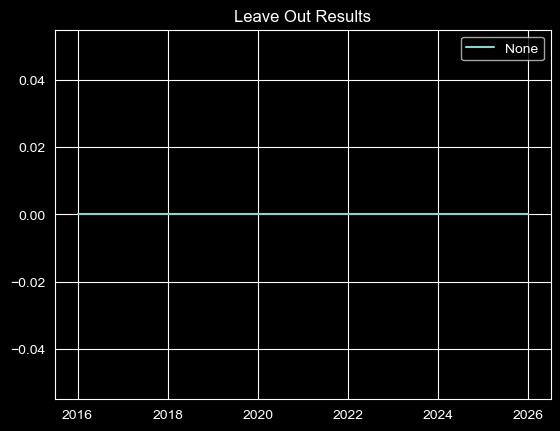

  Metric  RAGU_diff
0   None        0.0


In [22]:
leave_out_results_dict = dict()
waterfall_df = pd.DataFrame()
for leave_out in leave_out_list:
    RAGU_diff = np.abs(all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score).mean()
    waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    leave_out_results_dict[leave_out] = RAGU_diff
    plt.plot(all_leave_out_df.loc['None'].vintage.apply(vintage_to_float), all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score, label=leave_out)
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
print(pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff'))
waterfall_df.index = all_leave_out_df.loc['None'].vintage
#waterfall_df

In [23]:
leave_out_df#[np.array(leave_out_df.reset_index().vintage.apply(vintage_to_float)>=2022)]

,index,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,only_recovery_ragu,ms_100_ltv,ragu_score,leave_out
vintage,,,,,,,,,,,,,,,,,,,,,,,
2016 M01,non_kmxent,23702936.85,NaN,0.548857,2.055221,NaN,NaN,0.0,0.0,NaN,NaN,0.5,129.706948,129.373771,0.0,0.985381,0.0,129.706948,129.186587,-0.52036,129.706948,129.706948,None
2016 M02,non_kmxent,32787067.73,NaN,0.54532,1.976782,NaN,NaN,0.0,0.0,NaN,NaN,0.5,128.790631,128.217744,0.0,0.97903,0.0,128.790631,128.054245,-0.736386,128.790631,128.790631,None
2016 M03,non_kmxent,39102558.47,NaN,0.54653,1.990467,NaN,NaN,0.0,0.0,NaN,NaN,0.5,128.877454,128.341249,0.0,0.981203,0.0,128.877454,128.21547,-0.661984,128.877454,128.877454,None
2016 M04,non_kmxent,27327846.95,NaN,0.549141,2.017664,NaN,NaN,0.0,0.0,NaN,NaN,0.5,130.320609,129.786123,0.0,0.98589,0.0,130.320609,129.815728,-0.504882,130.320609,130.320609,None
2016 M05,non_kmxent,26900844.25,NaN,0.546073,1.981754,NaN,NaN,0.0,0.0,NaN,NaN,0.5,131.104193,130.563128,0.0,0.980382,0.0,131.104193,130.401953,-0.70224,131.104193,131.104193,None
2016 M06,non_kmxent,26805974.93,NaN,0.549782,1.950731,NaN,NaN,0.0,0.0,NaN,NaN,0.5,130.476485,130.049815,0.0,0.987041,0.0,130.476485,130.011678,-0.464808,130.476485,130.476485,None
2016 M07,non_kmxent,25608103.03,NaN,0.551807,1.950246,NaN,NaN,0.0,0.0,NaN,NaN,0.5,131.10151,130.723483,0.0,0.990677,0.0,131.10151,130.764301,-0.337209,131.10151,131.10151,None
2016 M08,non_kmxent,29513381.05,NaN,0.550809,1.963737,NaN,NaN,0.0,0.0,NaN,NaN,0.5,131.709955,131.32981,0.0,0.988884,0.0,131.709955,131.306753,-0.403202,131.709955,131.709955,None
2016 M09,non_kmxent,26598046.96,NaN,0.555379,1.975815,NaN,NaN,0.0,0.0,NaN,NaN,0.5,132.624957,131.920662,0.0,0.99709,0.0,132.624957,132.517775,-0.107182,132.624957,132.624957,None


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\3882856466.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1))


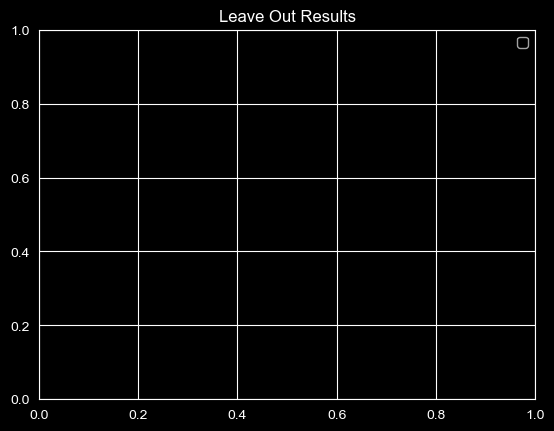

,Metric,RAGU_diff


In [24]:
leave_out_results_dict = dict()
for leave_out in leave_out_list:
    plt_df = waterfall_df[np.array(waterfall_df.reset_index().vintage.apply(vintage_to_float)>=2020)].reset_index()
    if (np.abs(plt_df['None'] - plt_df[leave_out])).mean() < 0.05:
        continue
    plt.plot(plt_df.vintage.apply(vintage_to_float), smooth(np.abs(plt_df['None'] - plt_df[leave_out])), label=leave_out)
    leave_out_results_dict[leave_out] = np.abs(plt_df['None'] - plt_df[leave_out]).mean()
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

In [25]:
store_pickle(vintages_dict, 'vintages_dict_pickle')

In [26]:
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

,Metric,RAGU_diff


# Export results to an Excel for manual inputs

In [27]:
import openpyxl
import pyodbc
import warnings
import pandas as pd
import datetime
import numpy as np
import re
import os
import copy

In [28]:
def excel_cell_to_index(cell_name):
    """
    Converts a cell name to its index; for example, 'B2' becomes (2, 2), since B is the second letter of the alphabet.
    """
    # Extract the column part from the cell name
    col_str = ''.join(filter(str.isalpha, cell_name)).upper()
    # Convert column letters to column index
    col_index = 0
    for i, char in enumerate(col_str):
        col_index = col_index * 26 + (ord(char) - ord('A')) + 1
    # Extract the row part from the cell name
    row_str = ''.join(filter(str.isdigit, cell_name))
    # Convert row string to row index
    row_index = int(row_str)
    return row_index, col_index
def overwrite_values(df, start_cell, worksheet):
    """
    Overwrites values in the given worksheet with the values in the given DataFrame, starting at the given cell name start_cell.
    """
    # Get the size of the DataFrame
    num_rows, num_cols = df.shape
    # Get starting cell indices
    start_cell_row, start_cell_col = excel_cell_to_index(start_cell)
    # Replace the data in the worksheet with the DataFrame
    for row in range(num_rows):
        for col in range(num_cols):
            cell = worksheet.cell(row=row+start_cell_row, column=col+start_cell_col)
            cell.value = df.iloc[row, col]
    return worksheet
def read_excel_selection(start_cell, end_cell, worksheet):
    """
    Converts a section of the worksheet to a Pandas DataFrame.
    """
    start_row, start_col = excel_cell_to_index(start_cell)
    end_row, end_col = excel_cell_to_index(end_cell)
    # Read data from the selected range into a list of lists
    data = []
    for row in range(start_row, end_row + 1):
        row_data = []
        for col in range(start_col, end_col + 1):
            cell = worksheet.cell(row=row, column=col)
            row_data.append(cell.value)
        data.append(row_data)
    return pd.DataFrame(data)
# This function returns the value contained within a given cell
excel_lookup = lambda cell: workbook[re.search(r'=(.*?)!', cell.value).group(1)][re.search(r'!(.*)', cell.value).group(1)]

In [29]:
# Be sure to rerun this code after hitting ctrl+s in the Excel document.
workbook = openpyxl.load_workbook('new_kmx_models.xlsx')

# Save Data Tables

### NonKMXENT

In [30]:
worksheet = workbook[f'Data Tables ({granularity.upper()})']

In [31]:
worksheet

<Worksheet "Data Tables (M)">

In [32]:
for lob, cell in zip(('AN', 'FRN', 'STG', 'non_kmxent'), ('B2', 'B20', 'B29', 'B47')):
    result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
    result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df = result_yearly_df.drop('amt_financed_x')
    for year in range(2016, 2020):
        year = str(year)
        metric_dict = dict()
        if granularity=='q':
            vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)]
        elif granularity == 'm':
            vintages_in_year = [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
        
        for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
            metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
        result_yearly_df[year] = pd.Series(metric_dict)
    result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
    result_yearly_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
    differences_df = full_result_df.copy()
    differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [33]:
correct_vintage_order = list(xlsx_df.columns)

### ENT, FLD

In [34]:
for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
    result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
    result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = result_df.copy()
    differences_df = full_result_df.copy()
    differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [35]:
# for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
#     result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
#     result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
#     result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
#     result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
#     full_result_df = result_df.copy()
#     differences_df = full_result_df.copy()
#     differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
#     differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
#     differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
#     differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
#     differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
#     differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
#     differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
#     xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T

In [36]:
# scratch = all_df_no_dropout.loc['ENT'][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']]#.reset_index(drop=True).set_index('vintage').T.copy()
# scratch.to_csv("scratch.csv")

### KMX

In [37]:
lob = 'KMX'
result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
result_df = result_yearly_df.drop('amt_financed_x')
for year in range(2016, 2020):
    year = str(year)
    metric_dict = dict()
    vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
    for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
        metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
    result_yearly_df[year] = pd.Series(metric_dict)
result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
result_yearly_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
differences_df = full_result_df.copy()
differences_df.loc['Mountain3 Score'] = full_result_df.loc['Mountain3 Score'] - full_result_df.loc['Contract Model Score']
differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Mountain3 Score']
differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
xlsx_df = differences_df.T[['Contract Model Score', 'Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
xlsx_df = xlsx_df[correct_vintage_order]
print(xlsx_df)
worksheet = overwrite_values(xlsx_df, 'B56', worksheet)

vintage                                     2016        2017        2018  \
Contract Model Score                  136.589578  139.090503  137.775522   
Mountain3 Score                         0.000000    0.000000    0.000000   
Gross Loss Adjustments                  3.992725    3.963412    3.760552   
Recovery Adjustments (Excluding LTV)   -1.567923   -2.603388   -2.587923   
LTV Adjustments                         1.567923    2.603388    2.587923   
RAGU Score                            140.582303  143.053915  141.536075   
LTV                                     1.586932    1.572015    1.585633   

vintage                                     2019    2020 M01    2020 M02  \
Contract Model Score                  136.874334  136.070894  136.072001   
Mountain3 Score                         0.000000    0.000000    0.000000   
Gross Loss Adjustments                  3.771731    3.702767    3.619782   
Recovery Adjustments (Excluding LTV)   -2.629983   -2.925488   -3.068907   
LTV Adjustm

### POS

In [38]:
lob = 'POS'
result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
result_df = result_yearly_df.drop('amt_financed_x')
for year in range(2016, 2020):
    year = str(year)
    metric_dict = dict()
    vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
    for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
        metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
    result_yearly_df[year] = pd.Series(metric_dict)
result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
result_yearly_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
differences_df = full_result_df.copy()
differences_df.loc['Modern Score'] = full_result_df.loc['Modern Score'] - full_result_df.loc['Contract Model Score']
differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Modern Score']
differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
xlsx_df = differences_df.T[['Contract Model Score', 'Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
worksheet = overwrite_values(xlsx_df, 'B65', worksheet)

# Distribution Data

In [39]:
with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    with open("distribution_query_temp.txt", "r") as file:
        temp_table_queries = file.read()
        conn.execute(temp_table_queries.strip())
        distribution_df = run_sql('distribution_query_current.txt', connection=conn)
distribution_df  = distribution_df.pivot(index = 'roa_dealer_group',columns = 'vintage', values = 'distribution')

worksheet = worksheet = workbook['distribution_rolledup']
worksheet = overwrite_values(distribution_df,'B3', worksheet)

In [40]:
distribution_df.to_csv('dist_df.csv')

# $t_{-1}$ Table

In [41]:
worksheet = workbook['t-1 Data Table']
run_query = False
if run_query or run_every_query:
    t_1_table = run_sql('select * from sandbox.t_1', filename_is_query=True)
    store_pickle(t_1_table, 't_1_table_pickle')
else:
    t_1_table = get_pickle('t_1_table_pickle')
latest_t_1 = pd.DataFrame(columns=t_1_table.columns)
for lob in t_1_table.roa_dealer_group.unique():
    latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])
latest_t_1 = latest_t_1.sort_values('lookup').set_index('roa_dealer_group').loc[['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'STG']]
worksheet = overwrite_values(latest_t_1, 'B2', worksheet)

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_21384\1305636891.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])


# Put Leave Out Analysis Waterfalls in Excel

In [42]:
worksheet = workbook['Waterfall Tables']
waterfall_df_dict = dict()
for lob, cell, lob_type in zip(['AN', 'FRN', 'STG', 'FLD', 'KMX', 'ENT'], 
                     ['B3', 'B48', 'B92', 'B135', 'B190', 'B164'],
                     ['non_kmxent']*4+['KMX', 'ENT']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    worksheet = overwrite_values(waterfall_df, cell, worksheet)

In [43]:
for lob, lob_type in zip(['FLD'], 
                        ['non_kmxent']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    waterfall_df.to_csv('waterfallFLD.csv')

In [44]:
workbook.save('new_kmx_models.xlsx')

In [45]:
mmi_lookup_df = pd.read_csv('../../Downloads/mmi_index_2019seasonality.csv').rename(columns={'mmi_2019_seasonality_index':'mmi'})
mmi_lookup_df['month'] = mmi_lookup_df.month_start.astype(str).str[:4] + '-' + mmi_lookup_df.month_start.astype(str).str[4:6]
mmi_lookup_df = mmi_lookup_df.drop(columns='month_start')
mmi_lookup_df

FileNotFoundError: [Errno 2] No such file or directory: '../../Downloads/mmi_index_2019seasonality.csv'

In [ ]:
pd.__version__

In [ ]:
pd.get_option('mode.copy_on_write')

In [ ]:
all_leave_out_df

In [ ]:
scratch = ula_df_total.loc[(ula_df_total['lob']=='KMX') & (ula_df_total['vintage']=='2025 M02')]
scratch.head()
